## Pandas fundamentals

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
names = ['Mercury', 'Venus', 'Earth']
values = [0.3e24, 4.87e24, 5.97e24]

In [3]:
masses = pd.Series(values, index=names)
masses

Mercury    3.000000e+23
Venus      4.870000e+24
Earth      5.970000e+24
dtype: float64

In [4]:
masses.shape

(3,)

In [5]:
masses.to_numpy()

array([3.00e+23, 4.87e+24, 5.97e+24])

In [6]:
masses.to_csv('mymassfile.csv')

In [7]:
masses2 = {'Mercury': 3e23, 'Venus':4.87e24, 'Earth':5.97e24}
masses2

{'Mercury': 3e+23, 'Venus': 4.87e+24, 'Earth': 5.97e+24}

In [8]:
myseries = pd.Series(masses2)
myseries

Mercury    3.000000e+23
Venus      4.870000e+24
Earth      5.970000e+24
dtype: float64

<Axes: >

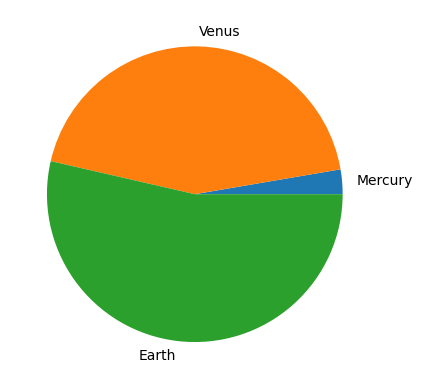

In [10]:
masses.plot(kind='pie')

In [11]:
newseries = np.log(masses)/masses**2

In [12]:
masses['Venus']

4.87e+24

In [17]:
data = {'mass': [0.3e24,4.87e24,5.97e24],
        'diameter': [4879e3,12104e3,12756e3], 
        'rotation_period': [1407.6, 'nan', 23.9]}
data

{'mass': [3e+23, 4.87e+24, 5.97e+24],
 'diameter': [4879000.0, 12104000.0, 12756000.0],
 'rotation_period': [1407.6, 'nan', 23.9]}

In [24]:
df = pd.DataFrame(data, index=names)
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,nan
Earth,5.970000e+24,12756000.0,23.9


In [25]:
describe = df.describe

In [26]:
describe.plot(kind='bar')

AttributeError: 'function' object has no attribute 'plot'

In [23]:
df.mean()

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [27]:
df['diameter']

Mercury     4879000.0
Venus      12104000.0
Earth      12756000.0
Name: diameter, dtype: float64

In [28]:
df.diameter.mean()

9913000.0

<Axes: >

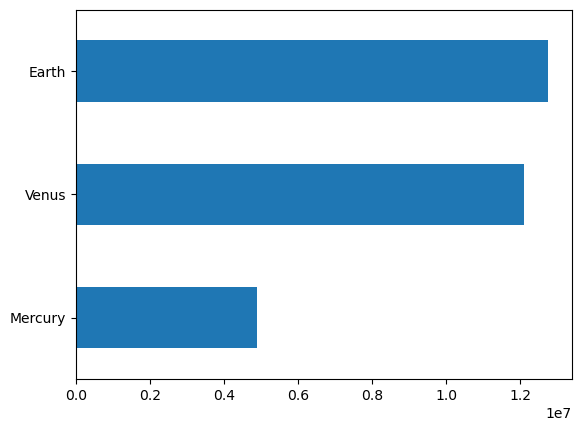

In [29]:
df.diameter.plot(kind='barh')

In [30]:
df.loc['Mercury']

mass               300000000000000008388608.0
diameter                            4879000.0
rotation_period                        1407.6
Name: Mercury, dtype: object

In [31]:
df.loc['Earth','mass']

5.97e+24

In [36]:
volume = 4/3*np.pi*(df.diameter / 2)**3
volume

Mercury    6.081225e+19
Venus      9.285074e+20
Earth      1.086781e+21
Name: diameter, dtype: float64

In [37]:
df.mass/volume

Mercury    4933.216530
Venus      5244.977070
Earth      5493.285577
dtype: float64

## merging data

In [41]:
temperature= pd.Series([167, 464, 15, -65],
                       index= ['Mercury','Venus','Earth','Mars'],
                        name= 'temperature')

In [44]:
df.join(temperature, how='right')

,mass,diameter,rotation_period,temperature
Mercury,3.000000e+23,4879000.0,1407.6,167
Venus,4.870000e+24,12104000.0,nan,464
Earth,5.970000e+24,12756000.0,23.9,15
Mars,NaN,NaN,NaN,-65


In [45]:
df.loc['Mars','diameter'] = 6.779e6
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,nan
Earth,5.970000e+24,12756000.0,23.9
Mars,NaN,6779000.0,NaN


In [46]:
df.loc['Mars', 'rotation_period'] = 24.5 
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,nan
Earth,5.970000e+24,12756000.0,23.9
Mars,NaN,6779000.0,24.5


In [48]:
df.loc['Mars', 'density'] = 3933
df

,mass,diameter,rotation_period,density
Mercury,3.000000e+23,4879000.0,1407.6,NaN
Venus,4.870000e+24,12104000.0,nan,NaN
Earth,5.970000e+24,12756000.0,23.9,NaN
Mars,NaN,6779000.0,24.5,3933.0


In [49]:
new_df = df.reindex(['Earth','Venus','Mars','Mercuty'])
new_df

,mass,diameter,rotation_period,density
Earth,5.970000e+24,12756000.0,23.9,NaN
Venus,4.870000e+24,12104000.0,nan,NaN
Mars,NaN,6779000.0,24.5,3933.0
Mercuty,NaN,NaN,NaN,NaN


In [50]:
another_df = df[['mass','density']]
another_df

,mass,density
Mercury,3.000000e+23,NaN
Venus,4.870000e+24,NaN
Earth,5.970000e+24,NaN
Mars,NaN,3933.0


In [51]:
df = df.join(temperature)

In [56]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    base_url="doi:10.5281/zenodo.5564850/",
registry={
    "data.txt": "md5:5129dcfd19300eb8d4d8d1673fcfbcb4",
},
)
datafile = POOCH.fetch("data.txt")
datafile

'/home/enh2134/.cache/noaa-data/data.txt'

In [58]:
df = pd.read_csv('/home/enh2134/.cache/noaa-data/data.txt',
                sep='\s+')
df

,WBANNO,LST_DATE,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
0,64756,20170101,2.422,-73.74,41.79,6.6,-5.4,0.6,2.2,0.0,...,-99.000,-99.000,0.207,0.152,0.175,-0.1,0.0,0.6,1.5,3.4
1,64756,20170102,2.422,-73.74,41.79,4.0,-6.8,-1.4,-1.2,0.0,...,-99.000,-99.000,0.205,0.151,0.173,-0.2,0.0,0.6,1.5,3.3
2,64756,20170103,2.422,-73.74,41.79,4.9,0.7,2.8,2.7,13.1,...,-99.000,-99.000,0.205,0.150,0.173,-0.1,0.0,0.5,1.5,3.3
3,64756,20170104,2.422,-73.74,41.79,8.7,-1.6,3.6,3.5,1.3,...,-99.000,-99.000,0.215,0.153,0.174,-0.1,0.0,0.5,1.5,3.2
4,64756,20170105,2.422,-73.74,41.79,-0.5,-4.6,-2.5,-2.8,0.0,...,-99.000,-99.000,0.215,0.154,0.177,-0.1,0.0,0.5,1.4,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,64756,20171227,2.622,-73.74,41.79,-6.7,-19.3,-13.0,-12.9,0.0,...,0.258,0.238,0.215,0.166,0.170,0.8,1.0,1.7,3.1,4.6
361,64756,20171228,2.622,-73.74,41.79,-10.3,-21.5,-15.9,-15.8,0.0,...,0.235,0.244,0.211,0.165,0.168,0.4,0.6,1.4,2.8,4.5
362,64756,20171229,2.622,-73.74,41.79,-9.4,-19.0,-14.2,-14.7,0.0,...,-99.000,-99.000,0.207,0.163,0.167,0.1,0.4,1.1,2.6,4.3
363,64756,20171230,2.622,-73.74,41.79,-7.1,-18.9,-13.0,-13.6,1.1,...,-99.000,-99.000,0.203,0.161,0.166,0.0,0.2,0.9,2.4,4.1


In [65]:
df = pd.read_csv('/home/enh2134/.cache/noaa-data/data.txt',
                sep='\s+', na_values=[-9999,-99],
                parse_dates=[1])

<Axes: >

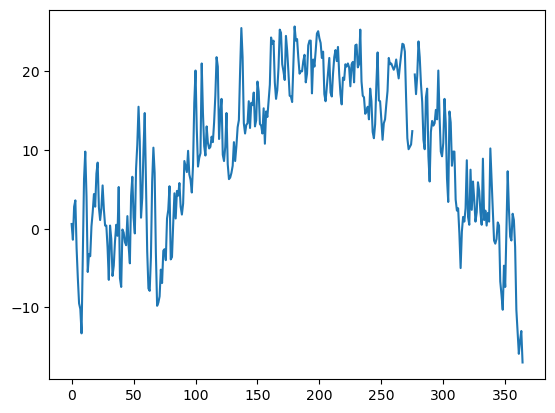

In [66]:
df.T_DAILY_MEAN.plot()

In [67]:
df.set_index('LST_DATE')

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2017-01-01,64756,2.422,-73.74,41.79,6.6,-5.4,0.6,2.2,0.0,8.68,...,NaN,NaN,0.207,0.152,0.175,-0.1,0.0,0.6,1.5,3.4
2017-01-02,64756,2.422,-73.74,41.79,4.0,-6.8,-1.4,-1.2,0.0,2.08,...,NaN,NaN,0.205,0.151,0.173,-0.2,0.0,0.6,1.5,3.3
2017-01-03,64756,2.422,-73.74,41.79,4.9,0.7,2.8,2.7,13.1,0.68,...,NaN,NaN,0.205,0.150,0.173,-0.1,0.0,0.5,1.5,3.3
2017-01-04,64756,2.422,-73.74,41.79,8.7,-1.6,3.6,3.5,1.3,2.85,...,NaN,NaN,0.215,0.153,0.174,-0.1,0.0,0.5,1.5,3.2
2017-01-05,64756,2.422,-73.74,41.79,-0.5,-4.6,-2.5,-2.8,0.0,4.90,...,NaN,NaN,0.215,0.154,0.177,-0.1,0.0,0.5,1.4,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,64756,2.622,-73.74,41.79,-6.7,-19.3,-13.0,-12.9,0.0,8.36,...,0.258,0.238,0.215,0.166,0.170,0.8,1.0,1.7,3.1,4.6
2017-12-28,64756,2.622,-73.74,41.79,-10.3,-21.5,-15.9,-15.8,0.0,8.46,...,0.235,0.244,0.211,0.165,0.168,0.4,0.6,1.4,2.8,4.5
2017-12-29,64756,2.622,-73.74,41.79,-9.4,-19.0,-14.2,-14.7,0.0,7.09,...,NaN,NaN,0.207,0.163,0.167,0.1,0.4,1.1,2.6,4.3


In [ ]:
df[[